<a href="https://colab.research.google.com/github/ladibakare/Deep-Learning-Application/blob/main/DeepLearning_Application_Pothole_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
import warnings
warnings.filterwarnings('ignore')


# Data Loading

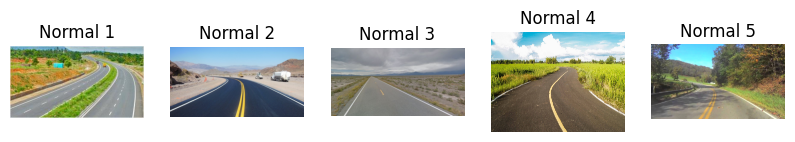

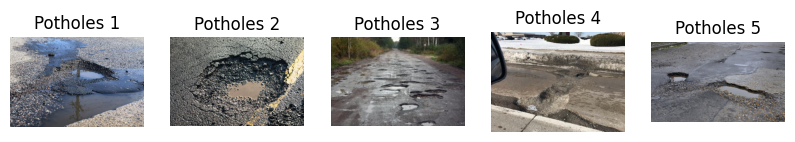

In [20]:
# Paths to dataset
normal_path = '/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes/Normal'
potholes_path = '/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes/Potholes'

# Function to display sample images
def show_samples(image_paths, title):
    plt.figure(figsize=(10, 5))
    for i, img_path in enumerate(image_paths[:5]):
        img = Image.open(img_path)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(f"{title} {i+1}")
        plt.axis('off')
    plt.show()

# Show samples for both classes
normal_images = glob(os.path.join(normal_path, '*.jpg'))
potholes_images = glob(os.path.join(potholes_path, '*.jpg'))

show_samples(normal_images, 'Normal')
show_samples(potholes_images, 'Potholes')

# Loading and Preprocessing Images

In [21]:
IMG_SIZE = (128, 128)

def preprocess_image(img):
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0  # Normalization
    return img

In [22]:
def load_and_preprocess_images(folder, label):
    images = []
    labels = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = preprocess_image(img)  # Preprocess the image
            images.append(img)
            labels.append(label)
    return images, labels

normal_images, normal_labels = load_and_preprocess_images('/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes/Normal', 0)
potholes_images, potholes_labels = load_and_preprocess_images('/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes/Potholes', 1)

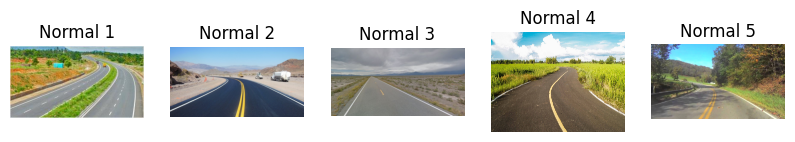

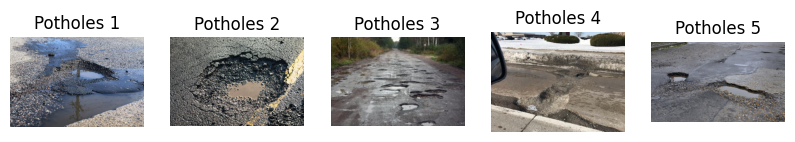

In [23]:
# Paths to dataset
normal_path = '/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes/Normal'
potholes_path = '/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes/Potholes'

# Function to display sample images
def show_samples(image_paths, title):
    plt.figure(figsize=(10, 5))
    for i, img_path in enumerate(image_paths[:5]):
        img = Image.open(img_path)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(f"{title} {i+1}")
        plt.axis('off')
    plt.show()

# Show samples for both classes
normal_images = glob(os.path.join(normal_path, '*.jpg'))
potholes_images = glob(os.path.join(potholes_path, '*.jpg'))

show_samples(normal_images, 'Normal')
show_samples(potholes_images, 'Potholes')

# Converting to Numpy

In [24]:
X = np.array(normal_images + potholes_images)
y = np.array(normal_labels + potholes_labels)

# Image Preprocessing - Resizing and Normalization

In [25]:
IMG_SIZE = (128, 128)

def preprocess_image(img_path):
    # Load the image from the path
    img = cv2.imread(img_path)
    if img is None:
        # Handle case where image could not be loaded (e.g., file not found, corrupted)
        print(f"Warning: Could not load image from {img_path}. Skipping.")
        return None
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    return img

# Apply the updated preprocessing function to each image path in X
X_processed_raw = [preprocess_image(path) for path in X]
# Filter out any None values if some images failed to load
X_processed = np.array([img for img in X_processed_raw if img is not None])

#Train-Test split

In [26]:
X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=42)

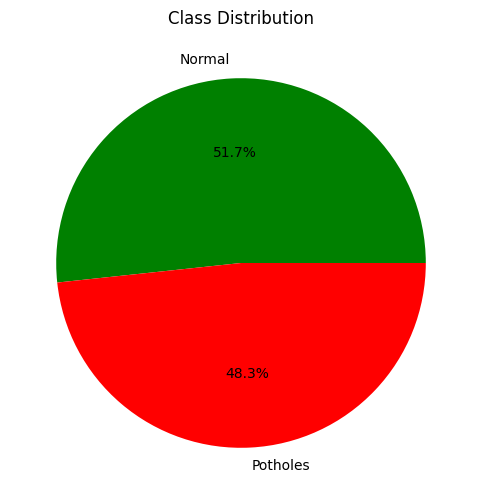

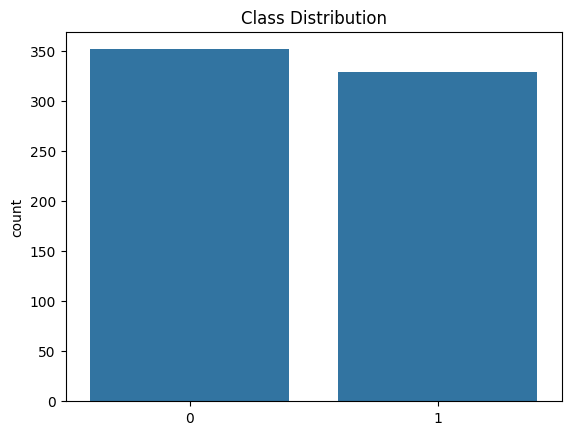

In [27]:
# Pie chart for class distribution
plt.figure(figsize=(6, 6))
plt.pie([np.sum(y == 0), np.sum(y == 1)], labels=['Normal', 'Potholes'], autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Class Distribution')
plt.show()

# Bar plot for class distribution
sns.countplot(x=y)
plt.title('Class Distribution')
plt.show()

#Baseline CNN Model

In [28]:
baseline_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

baseline_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = baseline_cnn.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.5257 - loss: 0.7531 - val_accuracy: 0.7372 - val_loss: 0.6663
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7022 - loss: 0.5687 - val_accuracy: 0.7080 - val_loss: 0.5161
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8474 - loss: 0.3465 - val_accuracy: 0.8540 - val_loss: 0.3476
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9007 - loss: 0.2507 - val_accuracy: 0.8540 - val_loss: 0.3011
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9099 - loss: 0.2562 - val_accuracy: 0.8540 - val_loss: 0.3529
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8915 - loss: 0.2644 - val_accuracy: 0.8321 - val_loss: 0.4541
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9191 - loss: 0.1722 - val_accuracy: 0.8467 - val_loss: 0.2823
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9449 - loss: 0.1520 - val_accuracy: 0.8905 - v

#Plotting the Loss Function Graph

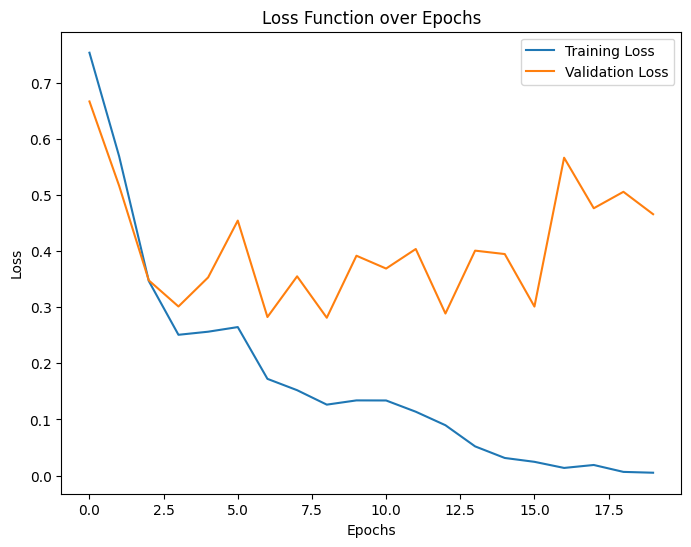

In [29]:
# Plot the training and validation loss over epochs
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Function over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Plot the Accuracy Graph

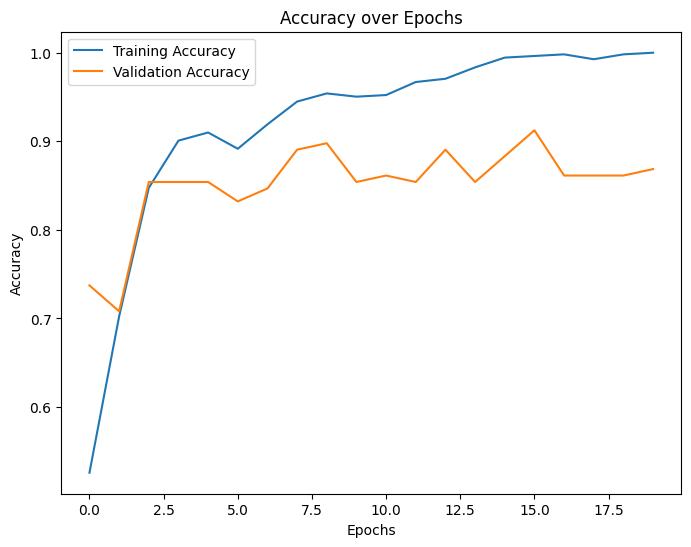

In [30]:
# Plot the training and validation accuracy over epochs
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Transfer Learning Models

Found 546 images belonging to 2 classes.
Found 135 images belonging to 2 classes.
Training VGG16
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 846ms/step - accuracy: 0.6355 - loss: 0.6356 - val_accuracy: 0.8741 - val_loss: 0.4892
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 636ms/step - accuracy: 0.8370 - loss: 0.4481 - val_accuracy: 0.8963 - val_loss: 0.3692
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 701ms/step - accuracy: 0.8846 - loss: 0.3635 - val_accuracy: 0.9333 - val_loss: 0.2791
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 655ms/step - accuracy: 0.9084 - loss: 0.2853 - val_accuracy: 0.9481 - val_loss: 0.2287
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 667ms/step - accuracy: 0.9231 - loss: 0.2448 - val_accuracy: 0.9556 - val_loss: 0.1931
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 643ms/step - accuracy: 0.9322 - loss: 0.2251 - val_accuracy: 0.9556 - val_loss: 0.1668
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 637ms/step - accuracy: 0.9341 - loss: 0.1960 - val_accuracy: 0.9481 - val_loss: 0.1517


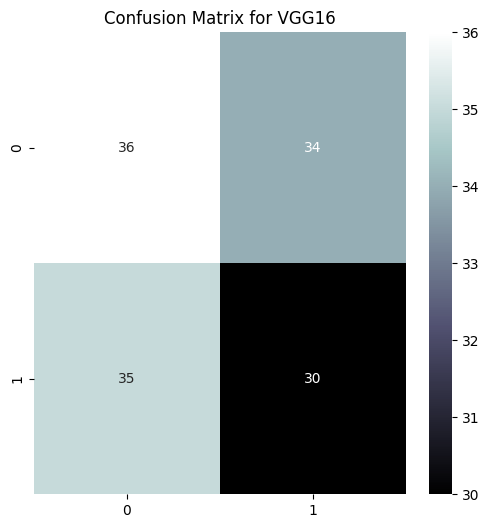

Classification Report for VGG16:
              precision    recall  f1-score   support

      Normal       0.51      0.51      0.51        70
    Potholes       0.47      0.46      0.47        65

    accuracy                           0.49       135
   macro avg       0.49      0.49      0.49       135
weighted avg       0.49      0.49      0.49       135

Accuracy: 97.78%



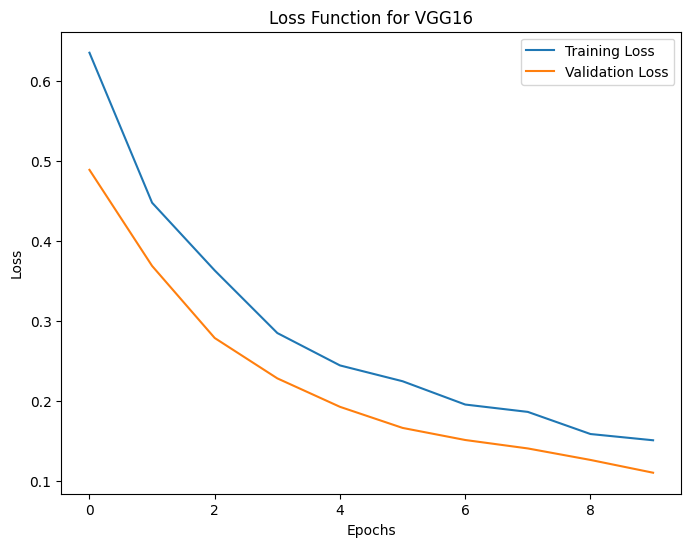

Training ResNet50
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5128 - loss: 0.7650 - val_accuracy: 0.5333 - val_loss: 0.6808
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 681ms/step - accuracy: 0.5201 - loss: 0.7034 - val_accuracy: 0.6370 - val_loss: 0.6776
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 623ms/step - accuracy: 0.5385 - loss: 0.6971 - val_accuracy: 0.5037 - val_loss: 0.6793
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 628ms/step - accuracy: 0.5623 - loss: 0.6881 - val_accuracy: 0.5852 - val_loss: 0.6736
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 662ms/step - accuracy: 0.6026 - loss: 0.6653 - val_accuracy: 0.4815 - val_loss: 0.6937
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 664ms/step - accuracy: 0.5604 - loss: 0.6870 - val_accuracy: 0.4815 - val_loss: 0.7006
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 708ms/step - accuracy: 0.5458 - loss: 0.6775 - val_accuracy: 0.5185 - val_loss: 0.6781
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 680ms/step - accuracy: 0.5476 - loss: 0.

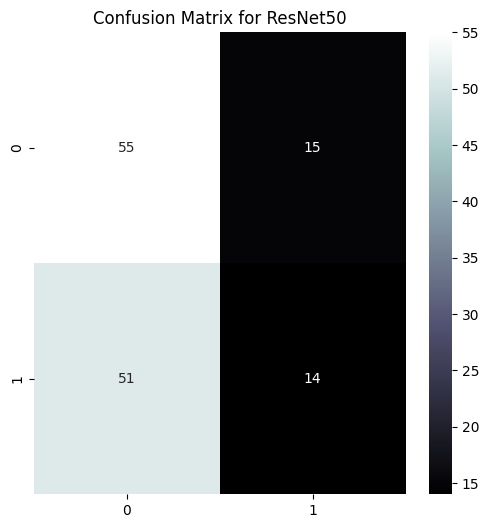

Classification Report for ResNet50:
              precision    recall  f1-score   support

      Normal       0.52      0.79      0.62        70
    Potholes       0.48      0.22      0.30        65

    accuracy                           0.51       135
   macro avg       0.50      0.50      0.46       135
weighted avg       0.50      0.51      0.47       135

Accuracy: 64.44%



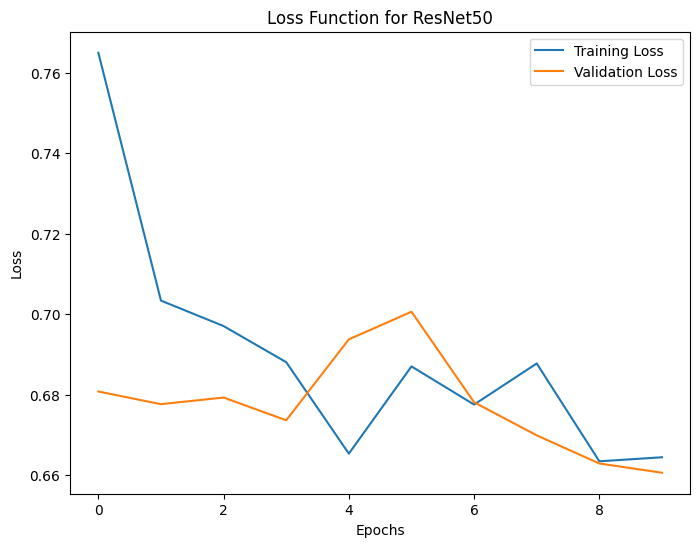

Training EfficientNetB0
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.4799 - loss: 0.7229 - val_accuracy: 0.5185 - val_loss: 0.6923
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 649ms/step - accuracy: 0.4670 - loss: 0.7054 - val_accuracy: 0.5630 - val_loss: 0.6930
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 607ms/step - accuracy: 0.5073 - loss: 0.6947 - val_accuracy: 0.5185 - val_loss: 0.6923
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 644ms/step - accuracy: 0.4908 - loss: 0.6967 - val_accuracy: 0.4815 - val_loss: 0.6934
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 653ms/step - accuracy: 0.5092 - loss: 0.6951 - val_accuracy: 0.5185 - val_loss: 0.6925
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 646ms/step - accuracy: 0.5238 - loss: 0.6939 - val_accuracy: 0.4815 - val_loss: 0.6932
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 595ms/step - accuracy: 0.5330 - loss: 0.6944 - val_accuracy: 0.4815 - val_loss: 0.6936
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 646ms/step - accuracy: 0.5183 - lo

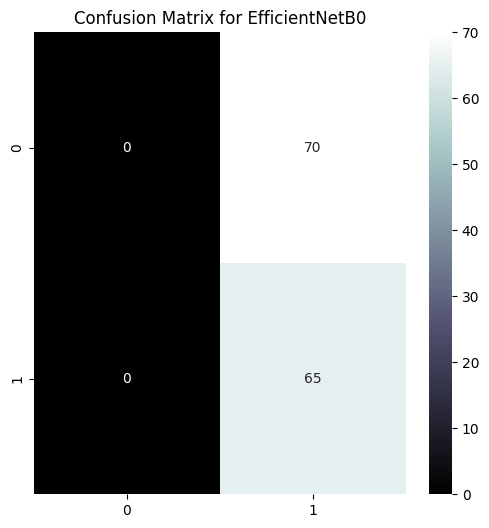

Classification Report for EfficientNetB0:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        70
    Potholes       0.48      1.00      0.65        65

    accuracy                           0.48       135
   macro avg       0.24      0.50      0.33       135
weighted avg       0.23      0.48      0.31       135

Accuracy: 48.15%



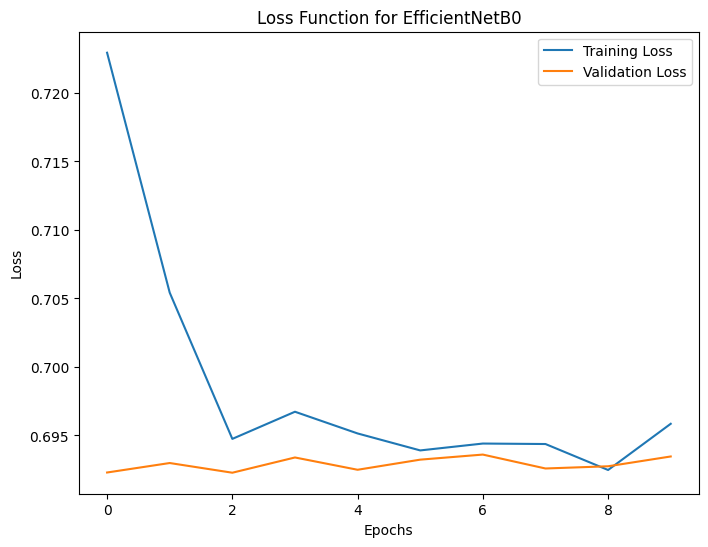

Training MobileNetV2
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8846 - loss: 0.2545 - val_accuracy: 0.9333 - val_loss: 0.1282
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 610ms/step - accuracy: 0.9652 - loss: 0.1214 - val_accuracy: 0.9111 - val_loss: 0.1868
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 636ms/step - accuracy: 0.9670 - loss: 0.0917 - val_accuracy: 0.9259 - val_loss: 0.1236
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 633ms/step - accuracy: 0.9762 - loss: 0.0675 - val_accuracy: 0.9333 - val_loss: 0.1422
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 637ms/step - accuracy: 0.9780 - loss: 0.0560 - val_accuracy: 0.9481 - val_loss: 0.1095
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 572ms/step - accuracy: 0.9799 - loss: 0.0477 - val_accuracy: 0.9556 - val_loss: 0.1060
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 650ms/step - accuracy: 0.9908 - loss: 0.0267 - val_accuracy: 0.9556 - val_loss: 0.1026
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 594ms/step - accuracy: 0.9927 - loss:

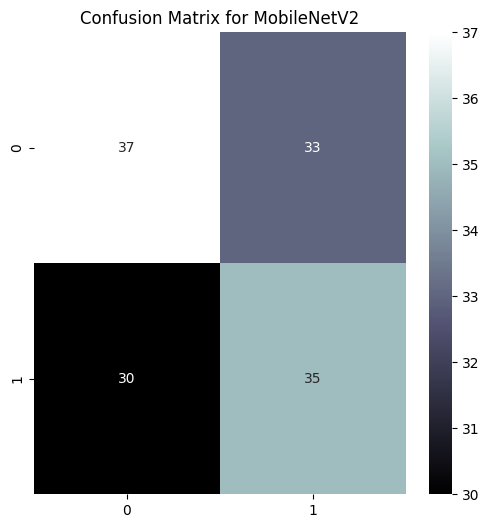

Classification Report for MobileNetV2:
              precision    recall  f1-score   support

      Normal       0.55      0.53      0.54        70
    Potholes       0.51      0.54      0.53        65

    accuracy                           0.53       135
   macro avg       0.53      0.53      0.53       135
weighted avg       0.53      0.53      0.53       135

Accuracy: 96.30%



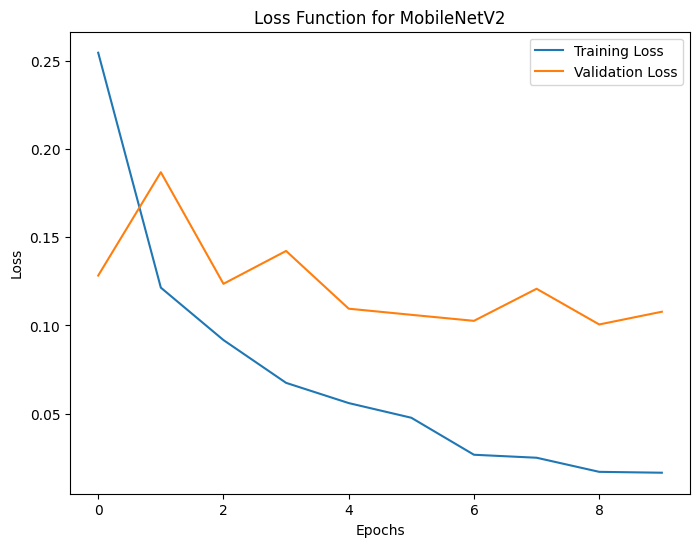

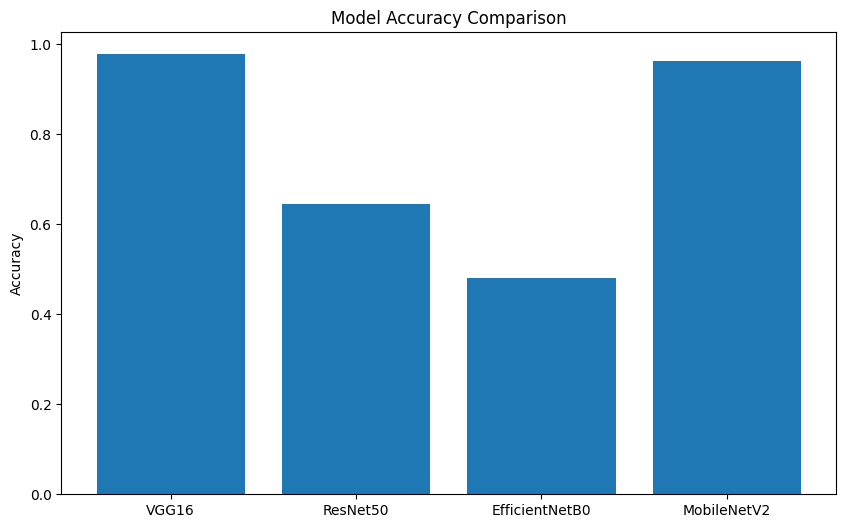

In [31]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, EfficientNetB0, DenseNet121, MobileNetV2, Xception
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Paths
normal_path = '/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes/Normal'
potholes_path = '/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes/Potholes'

# Image preprocessing
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen = datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes',
                                        target_size=(224, 224),
                                        batch_size=32,
                                        class_mode='binary',
                                        subset='training',
                                        classes=['Normal', 'Potholes']) # Explicitly define classes

val_gen = datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes',
                                      target_size=(224, 224),
                                      batch_size=32,
                                      class_mode='binary',
                                      subset='validation',
                                      classes=['Normal', 'Potholes']) # Explicitly define classes

# Model list
models = {
    'VGG16': VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    'ResNet50': ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    'EfficientNetB0': EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    'MobileNetV2': MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
}

# Function to add classification layers and compile models
def build_model(base_model):
    base_model.trainable = False
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train, evaluate and collect results
results = {}
for name, base_model in models.items():
    print(f"Training {name}")
    model = build_model(base_model)

    # Train the model
    history = model.fit(train_gen, validation_data=val_gen, epochs=10)

    # Evaluate on validation set
    val_pred = model.predict(val_gen)
    val_pred_labels = (val_pred > 0.5).astype(int)

    # The val_gen.classes attribute holds the original integer labels.
    # For binary classification (class_mode='binary'), these should be 0s and 1s.
    # If flow_from_directory detected more than 2 folders originally, val_gen.classes might contain values > 1.
    # We need to ensure y_true matches the binary labels (0 or 1) expected by the classification report.
    # Since we've explicitly set `classes=['Normal', 'Potholes']`, `val_gen.classes` should now correctly contain only 0s and 1s.
    y_true = val_gen.classes

    # Confusion Matrix and Classification Report
    # target_names will now correctly correspond to the two specified classes
    cm = confusion_matrix(y_true, val_pred_labels)
    cr = classification_report(y_true, val_pred_labels, target_names=list(val_gen.class_indices.keys()))

    # Store results
    results[name] = {
        'accuracy': history.history['val_accuracy'][-1],
        'loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
        'confusion_matrix': cm,
        'classification_report': cr
    }

    # Plot Confusion Matrix
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='bone')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

    # Print classification report
    print(f"Classification Report for {name}:\n{cr}")
    print(f"Accuracy: {results[name]['accuracy'] * 100:.2f}%\n")

    # Plot Loss Function Graphs
    plt.figure(figsize=(8,6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Function for {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Compare models' accuracy
accuracies = [results[model]['accuracy'] for model in models]
plt.figure(figsize=(10,6))
plt.bar(models.keys(), accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

<a id="lb"></a>
# <div style="background-color: #1a3636; font-family: 'Times New Roman', serif; font-size: 36px; color: #ffffff; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2);">Compact Convolutional Transformers (CCT)</div>

A Custom Compact Convolutional Transformer (CCT)

Steps to Implement Compact Convolutional Transformer (CCT)

Load and preprocess the dataset.

Build the CCT model.

Train the model.

Evaluate using the confusion matrix and classification report.

Plot the loss and accuracy graphs.

Found 546 images belonging to 3 classes.
Found 135 images belonging to 3 classes.


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │    51,380,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,751,553 (197.42 MB)

 Trainable params: 51,751,553 (197.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 894ms/step - accuracy: 0.4908 - loss: -40721.5391 - val_accuracy: 0.5185 - val_loss: -294761.4688
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 619ms/step - accuracy: 0.5165 - loss: -2934841.2500 - val_accuracy: 0.5185 - val_loss: -13621869.0000
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 618ms/step - accuracy: 0.5165 - loss: -57178556.0000 - val_accuracy: 0.5185 - val_loss: -159309648.0000
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 673ms/step - accuracy: 0.5165 - loss: -413826304.0000 - val_accuracy: 0.5185 - val_loss: -1041592384.0000
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 666ms/step - accuracy: 0.5165 - loss: -2182924800.0000 - val_accuracy: 0.5185 - val_loss: -4567522816.0000
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 655ms/step - accuracy: 0.5165 - loss: -8161254400.0000 - val_accuracy: 0.5185 - val_loss: -15064930304.0000
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 656ms/step - accuracy: 0.5165 - loss: -24138928128.0000 - val_accuracy: 0.5185 - 

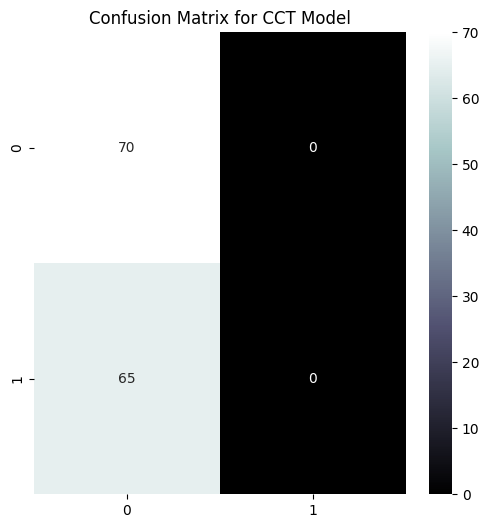

Classification Report for CCT Model:
              precision    recall  f1-score   support

           1       0.52      1.00      0.68        70
           2       0.00      0.00      0.00        65

    accuracy                           0.52       135
   macro avg       0.26      0.50      0.34       135
weighted avg       0.27      0.52      0.35       135



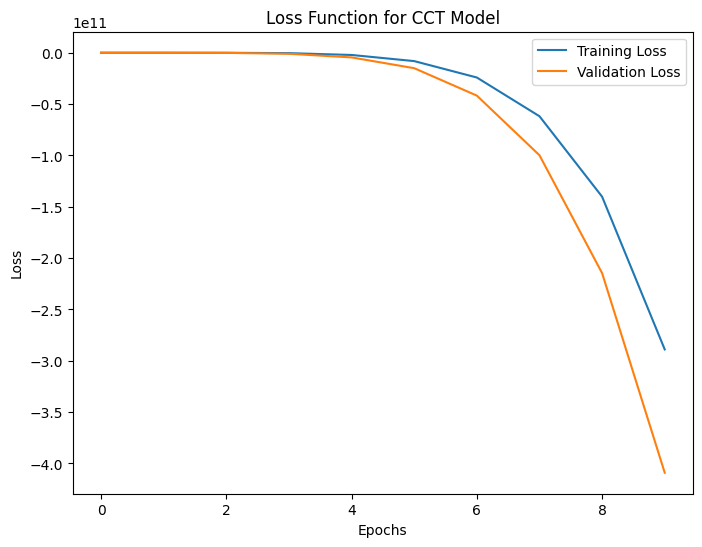

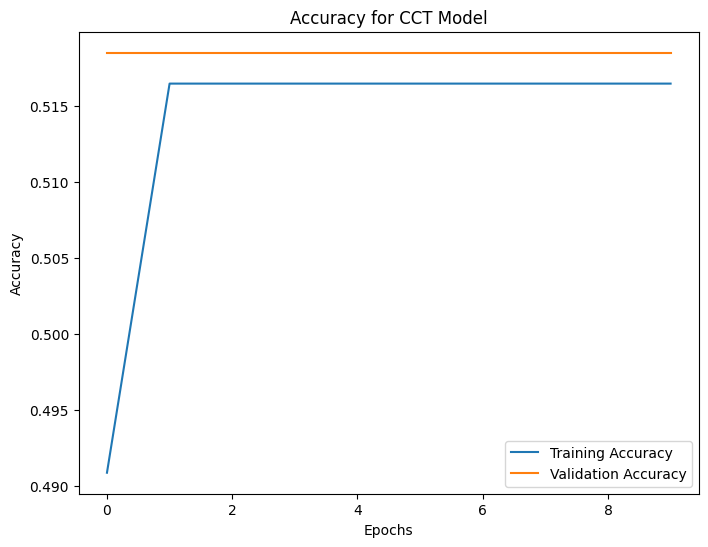

In [32]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Paths
normal_path = '/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes/Normal'
potholes_path = '/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes/Potholes'

# Image preprocessing
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen = datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes',
                                        target_size=(224, 224),
                                        batch_size=32,
                                        class_mode='binary',
                                        subset='training',
                                        shuffle=True)

val_gen = datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/ML Dataset/Kaggle_Potholes',
                                      target_size=(224, 224),
                                      batch_size=32,
                                      class_mode='binary',
                                      subset='validation',
                                      shuffle=False)

# Define a custom CCT model using Keras
def create_custom_cct_model():
    inputs = tf.keras.Input(shape=(224, 224, 3))

    # Convolutional layers to extract local features
    x = tf.keras.layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)

    x = tf.keras.layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)

    x = tf.keras.layers.Conv2D(256, kernel_size=3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=2)(x)

    # Flatten and dense layers for classification
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    # Output layer
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    # Create model
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Build and compile the CCT model
custom_cct_model = create_custom_cct_model()

# Model summary
custom_cct_model.summary()

# Train the model
history = custom_cct_model.fit(train_gen, validation_data=val_gen, epochs=10)

# Predictions
val_pred = custom_cct_model.predict(val_gen)
val_pred_labels = (val_pred > 0.5).astype(int)
y_true = val_gen.classes

# Confusion Matrix and Classification Report
cm = confusion_matrix(y_true, val_pred_labels)
cr = classification_report(y_true, val_pred_labels)

# Plot Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='bone')
plt.title('Confusion Matrix for CCT Model')
plt.show()

# Print classification report
print(f"Classification Report for CCT Model:\n{cr}")

# Plot Loss Function Graph
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Function for CCT Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Accuracy Graph
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy for CCT Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()